# London Air Pollution — Predicting Tomorrow's PM2.5
### A beginner-friendly time-series regression project

**How to read this notebook:** every section answers four questions — *where am I → what am I learning → why am I doing it → what does the result mean.*

| # | Section | # | Section |
|---|---|---|---|
| 1 | Project Introduction | 12 | Regression Metrics |
| 2 | Load and Understand the Data | 13 | Time-Series Cross-Validation |
| 3 | Data Quality | 14 | Hyperparameters and GridSearchCV |
| 4 | Exploratory Data Analysis | 15 | Model Comparison and Final Model |
| 5 | Date and Time Features | 16 | Actual vs Predicted |
| 6 | Feature Engineering | 17 | Error Analysis |
| 7 | Data Leakage | 18 | Feature Importance |
| 8 | Train / Validation / Test Split | 19 | Risk Analysis |
| 9 | Preprocessing | 20 | Limitations |
| 10 | Baseline Model | 21 | Final Conclusion |
| 11 | Machine Learning Models | | |

---
# Section 1 — Project Introduction

### What is the project?
Air pollution affects health. **PM2.5** (tiny particles smaller than 2.5 micrometres) is one of the most harmful pollutants. In this project we build a model that predicts **tomorrow's PM2.5** at one London monitoring station.

### What is the dataset?
The **AIR-01 London dataset** (Imperial College London, Zenodo, licence CC BY 4.0). It has **one row per day** from **1 Jan 2019 to 31 Dec 2022** (1,461 days) with pollution measurements from many stations, plus weather and satellite-based vegetation/building indices.

### What are we predicting?
The **daily PM2.5 at Camden–Bloomsbury** (column `UB_BL0_pm25`, an urban-background station), measured in **µg/m³**.

### Why is this a regression problem?
PM2.5 is a **continuous number** (for example 7.3 or 21.8), not a category. Predicting a number = **regression**.

### Why is it a *time-series* problem?
Each row is a day, and days come in order. Today's pollution is related to yesterday's. That means we must be careful: **we can never use the future to predict the past.**

### The workflow we will follow
**Understand → Explore → Prepare → Create Features → Prevent Leakage → Split → Train → Evaluate → Tune → Interpret → Conclude**

---
# Section 2 — Load and Understand the Data

**What we learn here:** what the data looks like.  **Why:** you cannot model data you do not understand.

We import only the libraries we need so far. Scikit-learn tools will be imported later, right where we first use them.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   # used only once, for the correlation heatmap

os.makedirs("../04_Figures", exist_ok=True)   # folder where we save our charts

In [2]:
df = pd.read_csv("../03_Data/Air-01-London_data.csv")
df.head()

,date,RS_IM1_no2,RS_CT4_no2,RS_CT6_no2,RS_SK8_no2,RS_WMC_no2,RS_GV2_no2,RS_MY1_no2,RS_WM6_no2,RS_WMB_no2,...,MR9_average_sndbi,MY1_average_sndbi,NB1_average_sndbi,SK6_average_sndbi,SK8_average_sndbi,WM0_average_sndbi,WM5_average_sndbi,WM6_average_sndbi,WMB_average_sndbi,WMC_average_sndbi
0,01/01/2019,50.708763,38.196157,41.768254,45.938900,38.398941,43.414632,40.625154,61.669356,60.031551,...,0.051289,0.051287,0.053039,0.051789,0.051615,0.051899,0.052250,0.050887,0.053565,0.052182
1,02/01/2019,68.333319,54.808397,43.401174,56.897043,47.789943,47.648556,42.951547,50.784047,66.273764,...,0.071330,0.071310,0.071626,0.066742,0.067792,0.061484,0.069693,0.065484,0.066677,0.066740
2,03/01/2019,78.677775,67.222794,65.910978,64.819630,58.005984,53.164893,50.758261,54.566081,80.828908,...,0.051289,0.051287,0.053039,0.051789,0.051615,0.051899,0.052250,0.050887,0.053565,0.052182
3,04/01/2019,69.721133,67.041547,65.343905,66.135769,62.591987,58.552238,54.475192,64.848712,82.282303,...,0.108331,0.108343,0.104136,0.106057,0.103491,0.105302,0.104735,0.107251,0.107987,0.107553
4,05/01/2019,63.985366,49.743969,56.900591,64.863952,58.483593,56.856692,50.972844,72.165087,77.281221,...,0.051289,0.051287,0.053039,0.051789,0.051615,0.051899,0.052250,0.050887,0.053565,0.052182


In [3]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (1461, 75)


In [4]:
print(list(df.columns))

['date', 'RS_IM1_no2', 'RS_CT4_no2', 'RS_CT6_no2', 'RS_SK8_no2', 'RS_WMC_no2', 'RS_GV2_no2', 'RS_MY1_no2', 'RS_WM6_no2', 'RS_WMB_no2', 'RS_NB1_no2', 'UB_BL0_no2', 'UB_CT3_no2', 'UB_SK6_no2', 'UB_WM5_no2', 'UB_WM0_no2', 'UB_CLL2_no2', 'UB_HORS_no2', 'RS_CT2_pm25', 'RS_MR9_pm25', 'UB_BL0_pm25', 'UB_CT3_pm25', 'UB_WM0_pm25', 'UB_HORS_pm25', 'RS_CT4_pm10', 'RS_MR9_pm10', 'RS_WMC_pm10', 'RS_WM6_pm10', 'RS_WMB_pm10', 'UB_BL0_pm10', 'UB_CT3_pm10', 'UB_SK6_pm10', 'UB_CLL2_pm10', 'air_temp', 'ws', 'wd', 'RH', 'BL0_average_ndvi', 'CLL2_average_ndvi', 'CT2_average_ndvi', 'CT3_average_ndvi', 'CT4_average_ndvi', 'CT6_average_ndvi', 'GV2_average_ndvi', 'HORS_average_ndvi', 'IM1_average_ndvi', 'MR9_average_ndvi', 'MY1_average_ndvi', 'NB1_average_ndvi', 'SK6_average_ndvi', 'SK8_average_ndvi', 'WM0_average_ndvi', 'WM5_average_ndvi', 'WM6_average_ndvi', 'WMB_average_ndvi', 'WMC_average_ndvi', 'BL0_average_sndbi', 'CLL2_average_sndbi', 'CT2_average_sndbi', 'CT3_average_sndbi', 'CT4_average_sndbi', 'CT6_a

In [5]:
df.info(verbose=False)   # verbose=False = short summary, because there are 75 columns

<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Columns: 75 entries, date to WMC_average_sndbi
dtypes: float64(74), str(1)
memory usage: 856.2 KB


In [6]:
important_columns = ["UB_BL0_pm25", "UB_BL0_pm10", "UB_BL0_no2", "air_temp", "ws", "wd", "RH"]
df[important_columns].describe().round(2)

,UB_BL0_pm25,UB_BL0_pm10,UB_BL0_no2,air_temp,ws,wd,RH
count,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00,1461.00
mean,9.87,16.83,26.61,12.06,3.91,192.84,75.39
std,7.41,9.32,13.54,5.60,1.74,73.12,12.10
min,0.27,1.57,4.58,-2.23,0.85,14.06,33.63
25%,5.29,11.04,16.62,7.84,2.59,145.93,66.37
50%,7.30,14.33,23.37,11.67,3.59,210.36,77.06
75%,11.79,19.32,34.64,16.54,4.95,245.18,84.97
max,55.58,81.29,89.56,29.86,12.45,339.49,97.74


### The important columns

The column names look cryptic, but they follow a pattern: **`site_pollutant`**. `UB` = urban background station, `RS` = roadside station.

| Group | Example column | Meaning |
|---|---|---|
| **Target** | `UB_BL0_pm25` | PM2.5 at Camden–Bloomsbury (µg/m³) — **what we predict** |
| PM2.5 (other sites) | `RS_CT2_pm25` | PM2.5 at other stations |
| PM10 | `UB_BL0_pm10` | Larger particles (< 10 micrometres) |
| NO₂ | `UB_BL0_no2` | Nitrogen dioxide, mainly from traffic |
| Weather | `air_temp`, `ws`, `wd`, `RH` | Temperature (°C), wind speed (m/s), wind direction (degrees), relative humidity (%) |
| Satellite | `..._average_ndvi`, `..._average_sndbi` | Vegetation index (NDVI) and built-up-area index (NDBI) |

In [7]:
group_counts = pd.Series({
    "PM2.5 columns": len(df.filter(like="_pm25").columns),
    "PM10 columns": len(df.filter(like="_pm10").columns),
    "NO2 columns": len(df.filter(like="_no2").columns),
    "Weather columns": 4,
    "NDVI columns": len(df.filter(like="_ndvi").columns),
    "NDBI columns": len(df.filter(like="_sndbi").columns),
})
group_counts

PM2.5 columns       6
PM10 columns        9
NO2 columns        17
Weather columns     4
NDVI columns       19
NDBI columns       19
dtype: int64

**What we see:** 1,461 rows × 75 columns. Everything is numeric except `date`, which was read as text.
**What it means:** we will need to convert `date` into a real date type before we can use it. The describe table shows the target (`UB_BL0_pm25`) averages roughly 10 µg/m³ but can reach more than 50.

---
# Section 3 — Data Quality

**What we learn here:** is the data trustworthy?  **Why:** bad data → bad model.

We check: missing values, duplicate rows, duplicate dates, unusual/negative values, and data types.

In [8]:
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate dates:", df["date"].duplicated().sum())

Total missing values: 0
Duplicate rows: 0
Duplicate dates: 0


**Data types.** The `date` column is text (it is written day/month/year, e.g. `01/01/2019`). We convert it to a real date and sort by date.

In [9]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")
df = df.sort_values("date").reset_index(drop=True)

print(df["date"].dtype)
print("First day:", df["date"].min().date(), "| Last day:", df["date"].max().date())

datetime64[us]
First day: 2019-01-01 | Last day: 2022-12-31


In [10]:
# Is every day present exactly once? The gap between consecutive dates should always be 1 day.
df["date"].diff().value_counts()

date
1 days    1460
Name: count, dtype: int64

**Unusual / negative values.** Pollution concentrations can never be negative. Let us check all pollution columns.

In [11]:
pollution = df.filter(regex="_(pm25|pm10|no2)$")      # all PM2.5, PM10 and NO2 columns
negative_counts = (pollution < 0).sum()
negative_counts[negative_counts > 0]

UB_HORS_pm25    1
dtype: int64

In [12]:
df.loc[df["UB_HORS_pm25"] < 0, ["date", "UB_HORS_pm25"]]

,date,UB_HORS_pm25
1003,2021-09-30,-0.625


In [13]:
# A negative concentration is a sensor error, so we replace it with "missing" (NaN).
df.loc[df["UB_HORS_pm25"] < 0, "UB_HORS_pm25"] = np.nan
df["UB_HORS_pm25"].isnull().sum()

np.int64(1)

**What we see:** no missing values, no duplicate rows, no duplicate dates, all 1,461 days present once, and **one** impossible negative PM2.5 value (at a *different* station from our target).

**What it means:** the data is in very good shape. (The dataset authors already filled gaps before publishing it, so this project does not claim credit for that step.) We replaced the one negative value with `NaN`; when we average stations later, pandas simply skips it. We did **not** remove high pollution days — those are real events, not errors.

*Note:* negative `air_temp` and NDVI values are normal (winter below 0 °C; NDVI is an index that can be negative), so we leave them alone.

---
# Section 4 — Exploratory Data Analysis (EDA)

**What we learn here:** the patterns in the data.  **Why:** patterns tell us which features are worth building.

We keep it to six important charts. Each one is followed by **What do we see? → What does it mean?**

### 4.1 Target distribution

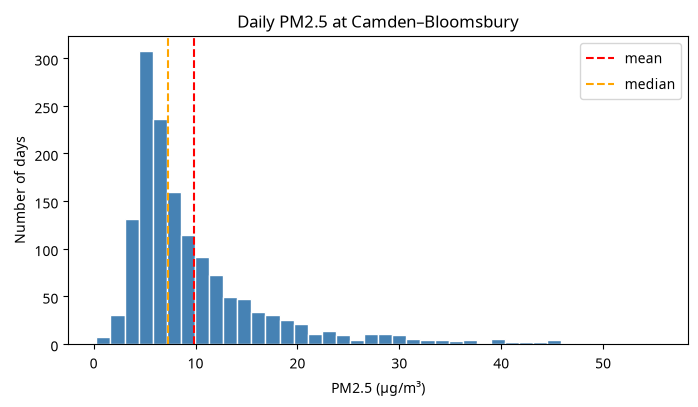

Mean: 9.87 | Median: 7.3 | Max: 55.58


In [14]:
target = "UB_BL0_pm25"

plt.figure(figsize=(8, 4))
plt.hist(df[target], bins=40, color="steelblue", edgecolor="white")
plt.axvline(df[target].mean(), color="red", linestyle="--", label="mean")
plt.axvline(df[target].median(), color="orange", linestyle="--", label="median")
plt.title("Daily PM2.5 at Camden–Bloomsbury")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Number of days")
plt.legend()
plt.savefig("../04_Figures/01_target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print("Mean:", round(df[target].mean(), 2), "| Median:", round(df[target].median(), 2), "| Max:", round(df[target].max(), 2))

**What we see:** the middle half of all days lie between about 5 and 12 µg/m³, with a long tail of high-pollution days. The mean is higher than the median.
**What it means:** the target is *right-skewed*. A few polluted days will be much harder to predict than the many ordinary days — keep this in mind for the error analysis later.

### 4.2 Target over time

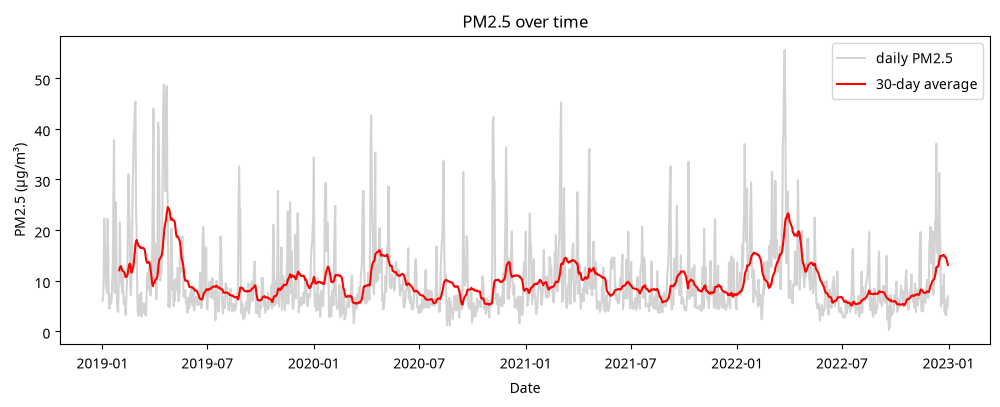

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df[target], color="lightgray", label="daily PM2.5")
plt.plot(df["date"], df[target].rolling(30).mean(), color="red", label="30-day average")
plt.title("PM2.5 over time")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.savefig("../04_Figures/02_target_over_time.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** the daily line is jagged, but the 30-day average moves slowly, with recurring peaks and valleys.
**What it means:** pollution has *memory* — high days tend to be followed by high days — and a repeating yearly rhythm. Both ideas will become features.

### 4.3 Monthly and seasonal pattern

In [16]:
# A quick preview: month number and season name (Section 5 explains date features properly)
df["month"] = df["date"].dt.month
df["season"] = df["month"].map({12: "Winter", 1: "Winter", 2: "Winter",
                                3: "Spring", 4: "Spring", 5: "Spring",
                                6: "Summer", 7: "Summer", 8: "Summer",
                                9: "Autumn", 10: "Autumn", 11: "Autumn"})

monthly_average = df.groupby("month")[target].mean()
monthly_average.round(2)

month
1     11.91
2     11.14
3     13.83
4     15.17
5      9.07
6      7.95
7      6.84
8      7.62
9      8.07
10     7.06
11    10.32
12     9.64
Name: UB_BL0_pm25, dtype: float64

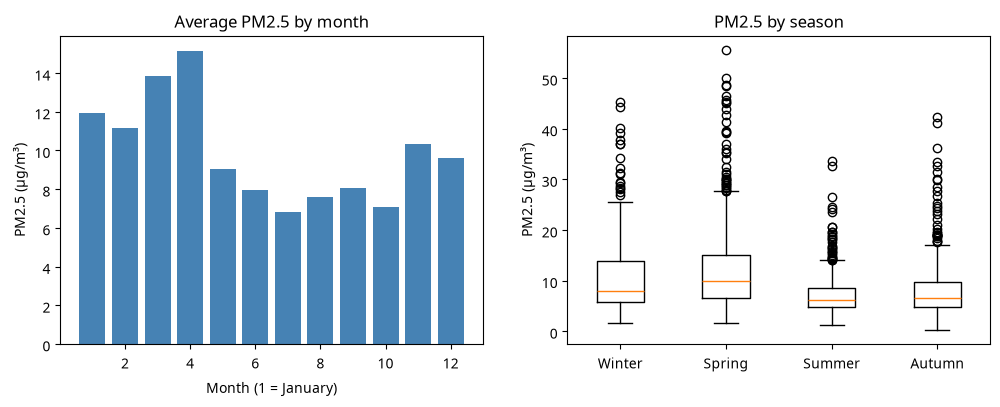

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(monthly_average.index, monthly_average.values, color="steelblue")
axes[0].set_title("Average PM2.5 by month")
axes[0].set_xlabel("Month (1 = January)")
axes[0].set_ylabel("PM2.5 (µg/m³)")

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_data = [df.loc[df["season"] == s, target] for s in season_order]
axes[1].boxplot(season_data, tick_labels=season_order)
axes[1].set_title("PM2.5 by season")
axes[1].set_ylabel("PM2.5 (µg/m³)")

plt.savefig("../04_Figures/03_monthly_and_seasonal_pattern.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** PM2.5 peaks in **March–April** (average about 14–15 µg/m³) and is lowest in **July and October** (about 7 µg/m³). By season, spring is highest (about 12.7), then winter (10.9), autumn (8.5) and summer (7.5). Spring and winter also have the longest "tails" of extreme days.
**What it means:** the time of year carries information, so month and season are worth trying as features.

### 4.4 Important feature relationships (weather)

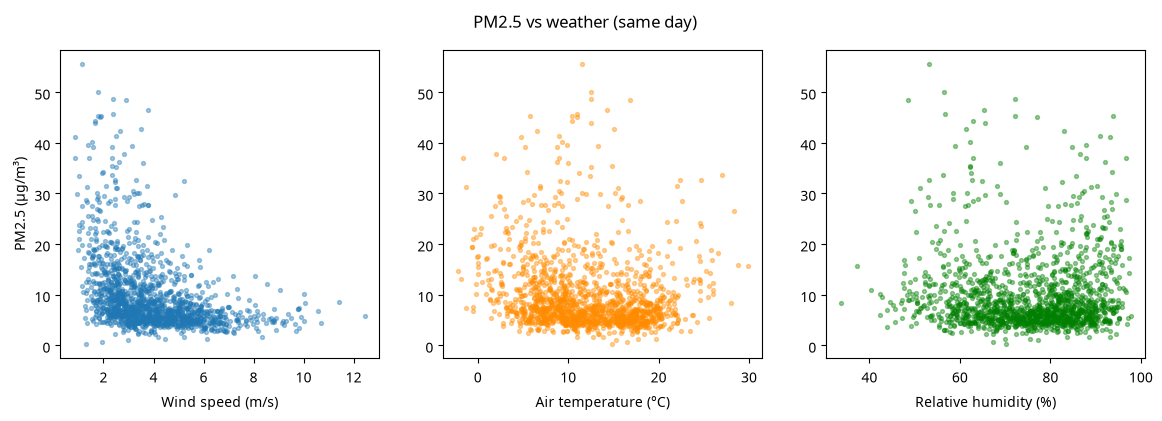

Average PM2.5 on calm days (wind < 2 m/s):   17.3
Average PM2.5 on windy days (wind > 6 m/s):  5.7


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(df["ws"], df[target], s=8, alpha=0.4)
axes[0].set_xlabel("Wind speed (m/s)")

axes[1].scatter(df["air_temp"], df[target], s=8, alpha=0.4, color="darkorange")
axes[1].set_xlabel("Air temperature (°C)")

axes[2].scatter(df["RH"], df[target], s=8, alpha=0.4, color="green")
axes[2].set_xlabel("Relative humidity (%)")

axes[0].set_ylabel("PM2.5 (µg/m³)")
fig.suptitle("PM2.5 vs weather (same day)")
plt.savefig("../04_Figures/04_pm25_vs_weather.png", dpi=120, bbox_inches="tight")
plt.show()

print("Average PM2.5 on calm days (wind < 2 m/s):  ", round(df.loc[df["ws"] < 2, target].mean(), 1))
print("Average PM2.5 on windy days (wind > 6 m/s): ", round(df.loc[df["ws"] > 6, target].mean(), 1))

**What we see:** on windy days PM2.5 is almost always low (never above about 19 µg/m³ when wind exceeds 6 m/s); on calm days it averages three times higher and can be very high. Temperature and humidity show weaker, noisier patterns.
**What it means:** wind blows pollution away, so weather is a sensible group of features. Calm weather does not *guarantee* high pollution — it just makes it possible.

### 4.5 Correlation

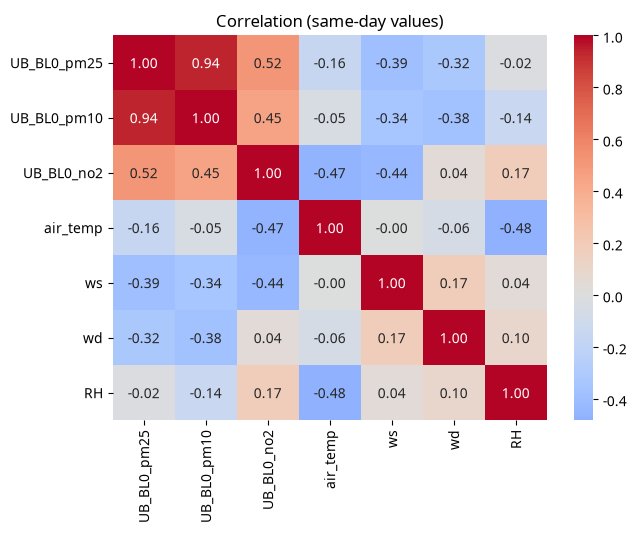

In [19]:
corr_columns = ["UB_BL0_pm25", "UB_BL0_pm10", "UB_BL0_no2", "air_temp", "ws", "wd", "RH"]
correlation = df[corr_columns].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation (same-day values)")
plt.savefig("../04_Figures/05_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** PM2.5 and PM10 at the same station are *very* strongly correlated (0.94). Wind speed is negatively correlated with PM2.5 (−0.39), and temperature and humidity only weakly (−0.16 and −0.02).
**What it means:** same-day PM10 looks like a perfect predictor — but when we forecast tomorrow we will **not yet have tomorrow's PM10**. This is a classic **data leakage trap**, covered in Section 7. Also, wind direction (`wd`, correlation −0.32) is a *circle* (359° is next to 1°), so a plain correlation can mislead us; we handle that in Section 6.

---
# Section 5 — Date and Time Features

**What we learn here:** how to turn a date into useful numbers.  **Why:** a model cannot read "2021-03-15", but it can use *month = 3* or *weekend = yes*.

Dates matter in this project because pollution follows **yearly rhythms** (seasons), **weekly rhythms** (traffic is lower at weekends), and **long-term memory** (yesterday predicts today).

Calendar information is safe to use: we always know tomorrow's date in advance.

In [20]:
df["year"] = df["date"].dt.year
df["day_of_week"] = df["date"].dt.dayofweek       # Monday = 0 ... Sunday = 6
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)   # 1 = Saturday/Sunday

df[["date", "year", "month", "day_of_week", "is_weekend", "season"]].head()

,date,year,month,day_of_week,is_weekend,season
0,2019-01-01,2019,1,1,0,Winter
1,2019-01-02,2019,1,2,0,Winter
2,2019-01-03,2019,1,3,0,Winter
3,2019-01-04,2019,1,4,0,Winter
4,2019-01-05,2019,1,5,1,Winter


In [21]:
print(df.groupby("day_of_week")[target].mean().round(2))
print()
print(df.groupby("year")[target].mean().round(2))

day_of_week
0     9.56
1     9.95
2    10.38
3     9.87
4     9.85
5     9.93
6     9.55
Name: UB_BL0_pm25, dtype: float64

year
2019    10.77
2020     9.16
2021     9.34
2022    10.21
Name: UB_BL0_pm25, dtype: float64


**What we see:** `month` and `season` (created in Section 4) are now joined by `year`, `day_of_week` and `is_weekend`. Weekday differences are small. Average PM2.5 changes from year to year.

**What it means / our choice:**
- We **will** use `month`, `season` and `is_weekend`.
- We will **not** use `year` as a model feature. Our final test is the year 2022, which the model never sees during training — a model cannot learn what "2022" means. The year would only be a shortcut that fails on new data.

---
# Section 6 — Feature Engineering

**What we learn here:** how to build features from the *past*.  **Why:** the best clue for tomorrow's pollution is what happened in the last few days.

### What is a lag?
A **lag** is the value from some days ago. *Lag 1* = yesterday, *lag 2* = two days ago.

In pandas this is `shift()`. Simple example from our first six days:

In [22]:
example = df[["date", target]].head(6).copy()
example["lag1 (yesterday)"] = example[target].shift(1)
example["lag2 (2 days ago)"] = example[target].shift(2)
example

,date,UB_BL0_pm25,lag1 (yesterday),lag2 (2 days ago)
0,2019-01-01,6.029167,NaN,NaN
1,2019-01-02,6.466667,6.029167,NaN
2,2019-01-03,9.676190,6.466667,6.029167
3,2019-01-04,22.275000,9.676190,6.466667
4,2019-01-05,19.341667,22.275000,9.676190
5,2019-01-06,16.162500,19.341667,22.275000


Read it row by row: on 3 Jan, *lag 1* is the value from 2 Jan, and *lag 2* is the value from 1 Jan. The first rows have `NaN` because there is no earlier day.

We will predict the value in column 2 (**the target for day *t***) using columns that only look backwards.

### Does yesterday really help?

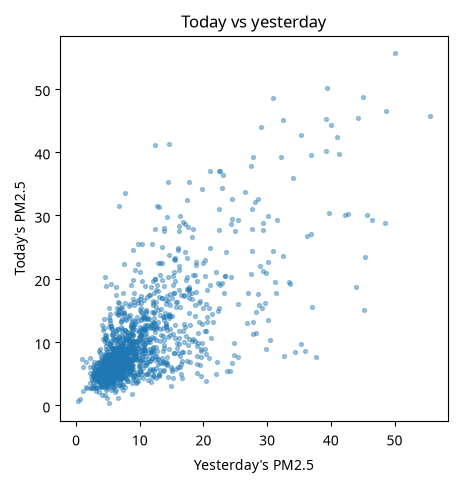

Correlation with 1 day ago: 0.72
Correlation with 2 days ago: 0.49
Correlation with 3 days ago: 0.33


In [23]:
df["pm25_lag1"] = df[target].shift(1)

plt.figure(figsize=(5, 5))
plt.scatter(df["pm25_lag1"], df[target], s=8, alpha=0.4)
plt.xlabel("Yesterday's PM2.5")
plt.ylabel("Today's PM2.5")
plt.title("Today vs yesterday")
plt.savefig("../04_Figures/06_today_vs_yesterday.png", dpi=120, bbox_inches="tight")
plt.show()

print("Correlation with 1 day ago:", round(df[target].autocorr(lag=1), 2))
print("Correlation with 2 days ago:", round(df[target].autocorr(lag=2), 2))
print("Correlation with 3 days ago:", round(df[target].autocorr(lag=3), 2))

**What we see:** the points follow a clear upward trend, and the correlation fades as we look further back (lag 1 > lag 2 > lag 3).
**What it means:** yesterday is the single best clue we have. This is called **autocorrelation**.

### Lag features of the target

In [24]:
df["pm25_lag2"] = df[target].shift(2)
df["pm25_lag3"] = df[target].shift(3)

### Rolling means
A **rolling mean** is the average of the last few days. It smooths out daily noise.

⚠️ **Important:** we write `.shift(1)` *before* `.rolling(...)`. That way the rolling window covers the days **before** today. Without the shift, today's own value would be inside its own feature (a leak — see Section 7).

In [25]:
df["pm25_roll3"] = df[target].shift(1).rolling(3).mean()   # average of the 3 days before today
df["pm25_roll7"] = df[target].shift(1).rolling(7).mean()   # average of the 7 days before today

df[["date", target, "pm25_lag1", "pm25_roll3", "pm25_roll7"]].iloc[7:12]

,date,UB_BL0_pm25,pm25_lag1,pm25_roll3,pm25_roll7
7,2019-01-08,8.325000,9.633333,15.045833,12.797789
8,2019-01-09,7.479167,8.325000,11.373611,13.125765
9,2019-01-10,22.220833,7.479167,8.479167,13.270408
10,2019-01-11,14.937500,22.220833,12.675000,15.062500
11,2019-01-12,5.962500,14.937500,14.879167,14.014286


### Other lagged environmental features
We use the same idea for the other measurements: **yesterday's** weather, PM10, NO₂, and the average PM2.5 across all stations ("city PM2.5").

In [26]:
# Average PM2.5 over all PM2.5 stations (pandas skips the one NaN we created)
pm25_columns = df.filter(like="_pm25").columns
df["city_pm25"] = df[pm25_columns].mean(axis=1)

df["city_pm25_lag1"] = df["city_pm25"].shift(1)
df["pm10_lag1"] = df["UB_BL0_pm10"].shift(1)
df["no2_lag1"] = df["UB_BL0_no2"].shift(1)

df["temp_lag1"] = df["air_temp"].shift(1)
df["ws_lag1"] = df["ws"].shift(1)
df["rh_lag1"] = df["RH"].shift(1)

df["ws_roll3"] = df["ws"].shift(1).rolling(3).mean()
df["temp_roll3"] = df["air_temp"].shift(1).rolling(3).mean()

### Wind direction is a circle
Wind direction is measured in degrees (0–360). But **359° and 1° are almost the same direction**, even though the numbers are far apart. Let us see if direction matters:

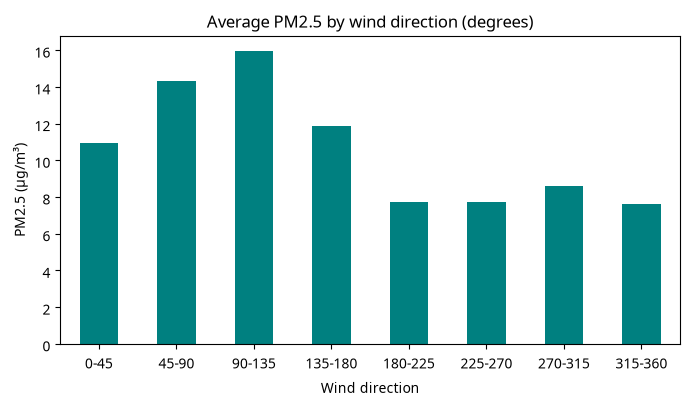

In [27]:
sector_names = ["0-45", "45-90", "90-135", "135-180", "180-225", "225-270", "270-315", "315-360"]
df["wind_sector"] = pd.cut(df["wd"], bins=[0, 45, 90, 135, 180, 225, 270, 315, 360], labels=sector_names)

plt.figure(figsize=(8, 4))
df.groupby("wind_sector", observed=True)[target].mean().plot(kind="bar", color="teal")
plt.title("Average PM2.5 by wind direction (degrees)")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Wind direction")
plt.xticks(rotation=0)
plt.savefig("../04_Figures/07_wind_direction.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** when the wind comes from the **east or south-east (45–135°)**, average PM2.5 is about 14–16 µg/m³ — roughly double the level (about 8) when it comes from the south-west or west (180–315°). (The 315–360° bar is based on only 19 days.)
**What it means:** direction clearly matters, but a plain number (0–360) is awkward for a model. The standard trick is to turn the angle into two numbers, **sine** and **cosine**, which put the direction on a circle.

In [28]:
angle = np.deg2rad(df["wd"])              # degrees -> radians
df["wd_sin_lag1"] = np.sin(angle).shift(1)
df["wd_cos_lag1"] = np.cos(angle).shift(1)

### Satellite indices
Vegetation (NDVI) and built-up area (NDBI) barely change from day to day, so we expect them to be weak features. We include one city-wide average of each, to test that assumption.

In [29]:
df["ndvi_lag1"] = df.filter(like="_ndvi").mean(axis=1).shift(1)
df["ndbi_lag1"] = df.filter(like="_sndbi").mean(axis=1).shift(1)

### The final feature list
We keep **19 numeric features + 1 categorical (`season`)**. All are either **from yesterday or earlier**, or **calendar facts known in advance**. We drop the first few rows because lags and rolling means need earlier days.

In [30]:
numeric_features = [
    "pm25_lag1", "pm25_lag2", "pm25_lag3", "pm25_roll3", "pm25_roll7",   # target history
    "city_pm25_lag1", "pm10_lag1", "no2_lag1",                           # other pollution (yesterday)
    "temp_lag1", "ws_lag1", "rh_lag1", "wd_sin_lag1", "wd_cos_lag1",     # weather (yesterday)
    "ws_roll3", "temp_roll3",                                            # recent weather average
    "ndvi_lag1", "ndbi_lag1",                                            # satellite
    "month", "is_weekend",                                               # calendar
]
categorical_features = ["season"]
features = numeric_features + categorical_features

model_df = df[["date", target] + features].dropna().reset_index(drop=True)
print("Rows before:", len(df), "| Rows after dropping the first days:", len(model_df))
print("First usable day:", model_df["date"].min().date())
model_df.head()

Rows before: 1461 | Rows after dropping the first days: 1454
First usable day: 2019-01-08


,date,UB_BL0_pm25,pm25_lag1,pm25_lag2,pm25_lag3,pm25_roll3,pm25_roll7,city_pm25_lag1,pm10_lag1,no2_lag1,...,rh_lag1,wd_sin_lag1,wd_cos_lag1,ws_roll3,temp_roll3,ndvi_lag1,ndbi_lag1,month,is_weekend,season
0,2019-01-08,8.325000,9.633333,16.162500,19.341667,15.045833,12.797789,11.087717,18.362500,46.852265,...,82.759,-0.978785,-0.204889,3.409333,7.157333,-1.601659,0.055888,1,0,Winter
1,2019-01-09,7.479167,8.325000,9.633333,16.162500,11.373611,13.125765,9.721455,19.912500,44.500889,...,71.474,-0.793375,0.608734,3.932000,7.977000,-1.131260,0.052296,1,0,Winter
2,2019-01-10,22.220833,7.479167,8.325000,9.633333,8.479167,13.270408,8.979572,15.804167,47.825742,...,77.431,-0.350404,0.936599,4.179333,6.797000,-1.072217,0.092400,1,0,Winter
3,2019-01-11,14.937500,22.220833,7.479167,8.325000,12.675000,15.062500,23.780782,31.083333,60.493240,...,87.914,-0.890427,0.455125,3.146000,4.780000,-1.131260,0.052296,1,0,Winter
4,2019-01-12,5.962500,14.937500,22.220833,7.479167,14.879167,14.014286,15.644229,20.666667,54.179885,...,83.147,-0.829915,0.557890,2.572000,4.906667,-1.131260,0.052296,1,1,Winter


---
# Section 7 — Data Leakage

**What we learn here:** the most common way time-series projects fool themselves.

### What is data leakage?
**Data leakage** is when the model sees information during training or testing that it would **not** have in real life when making the prediction. The model then looks great on paper but fails in reality.

### The rule for this project
> To predict PM2.5 for day *t*, the model may only use information from **day *t−1 or earlier***, plus calendar facts known in advance.

### Leak example 1 — same-day measurements
Same-day PM10 is almost the same thing as same-day PM2.5. Let us see what happens if we cheat. *(This is a quick demo only — the cheating model is thrown away. It uses 2019 → mid-2021 to learn and the second half of 2021 to check; 2022 is not touched.)*

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

demo = df[["date", target, "UB_BL0_pm10", "pm25_lag1"]].dropna()
demo_train = demo[demo["date"] <= "2021-06-30"]
demo_check = demo[(demo["date"] >= "2021-07-01") & (demo["date"] <= "2021-12-31")]

# CHEATING model: uses today's PM10 (we would not have this when predicting)
cheat = LinearRegression().fit(demo_train[["UB_BL0_pm10"]], demo_train[target])
r2_cheat = r2_score(demo_check[target], cheat.predict(demo_check[["UB_BL0_pm10"]]))

# HONEST model: uses yesterday's PM2.5 only
honest = LinearRegression().fit(demo_train[["pm25_lag1"]], demo_train[target])
r2_honest = r2_score(demo_check[target], honest.predict(demo_check[["pm25_lag1"]]))

print("R² with same-day PM10 (leaky):  ", round(r2_cheat, 2))
print("R² with yesterday's PM2.5 (safe):", round(r2_honest, 2))

R² with same-day PM10 (leaky):   0.69
R² with yesterday's PM2.5 (safe): 0.18


**What we see:** the cheating model looks far better (R² about 0.69 instead of 0.18).
**What it means:** that excellent score is **fake**. At 6 pm today we do not know tomorrow's PM10. A leaky model gives you confidence you have not earned.

### Leak example 2 — a rolling mean that includes today

In [32]:
leaky_roll3 = df[target].rolling(3).mean()            # WRONG: includes today's value
safe_roll3 = df[target].shift(1).rolling(3).mean()    # RIGHT: only the 3 days before today

print("Correlation with today's PM2.5 (leaky rolling mean):", round(leaky_roll3.corr(df[target]), 2))
print("Correlation with today's PM2.5 (safe rolling mean): ", round(safe_roll3.corr(df[target]), 2))

Correlation with today's PM2.5 (leaky rolling mean): 0.84
Correlation with today's PM2.5 (safe rolling mean):  0.59


**What we see:** the leaky version correlates much more strongly with the target.
**What it means:** it does so because the target itself is hiding inside it. That is why every rolling feature in Section 6 uses `.shift(1)` first.

### Other ways leakage can happen (and how we avoid them)
| Leak | How we avoid it |
|---|---|
| Random train/test split mixes future days into training | Chronological split (Section 8) |
| Scaling using the mean of *all* data | Fit scaler on training data only (Section 9) |
| Choosing a model by peeking at the test set | Test set used **once**, at the very end (Section 15) |
| Cross-validation with shuffled folds | `TimeSeriesSplit` (Section 13) |

### Our leakage check
Our features should contain no same-day measurements, and `pm25_lag1` on each row should equal the target of the **previous** row.

In [33]:
print("Target used as a feature?", target in features)
print("Features:", features)

same_as_yesterday = (model_df["pm25_lag1"].iloc[1:].values == model_df[target].iloc[:-1].values).all()
print("pm25_lag1 equals the previous day's target on every row:", same_as_yesterday)

Target used as a feature? False
Features: ['pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_roll3', 'pm25_roll7', 'city_pm25_lag1', 'pm10_lag1', 'no2_lag1', 'temp_lag1', 'ws_lag1', 'rh_lag1', 'wd_sin_lag1', 'wd_cos_lag1', 'ws_roll3', 'temp_roll3', 'ndvi_lag1', 'ndbi_lag1', 'month', 'is_weekend', 'season']
pm25_lag1 equals the previous day's target on every row: True


---
# Section 8 — Train / Validation / Test Split

**What we learn here:** how to split time-ordered data.  **Why:** to measure how the model behaves on days it has never seen.

### Why not a random `train_test_split`?
A random split would put some 2022 days in training and some 2019 days in testing. The model would "learn" from the future. In real life you can only learn from the past, so we split **by date**:

**Training** (learn) → **Validation** (compare and tune models) → **Final test** (judge the one chosen model, once)

- **Training:** start → 30 June 2021
- **Validation:** 1 July 2021 → 31 December 2021
- **Final test:** all of 2022 — **kept untouched until Section 15**

The test set must stay untouched because every time we look at test results and change something, we *tune the model to the test set*, and the test score stops being an honest estimate.

In [34]:
train_mask = model_df["date"] <= "2021-06-30"
val_mask = (model_df["date"] >= "2021-07-01") & (model_df["date"] <= "2021-12-31")
test_mask = model_df["date"] >= "2022-01-01"

X_train, y_train = model_df.loc[train_mask, features], model_df.loc[train_mask, target]
X_val, y_val = model_df.loc[val_mask, features], model_df.loc[val_mask, target]
X_test, y_test = model_df.loc[test_mask, features], model_df.loc[test_mask, target]

In [35]:
split_table = pd.DataFrame({
    "First day": [model_df.loc[m, "date"].min().date() for m in [train_mask, val_mask, test_mask]],
    "Last day": [model_df.loc[m, "date"].max().date() for m in [train_mask, val_mask, test_mask]],
    "Rows": [len(y_train), len(y_val), len(y_test)],
    "Mean PM2.5": [y_train.mean(), y_val.mean(), y_test.mean()],
    "Std PM2.5": [y_train.std(), y_val.std(), y_test.std()],
}, index=["Training", "Validation", "Test"]).round(2)
split_table

,First day,Last day,Rows,Mean PM2.5,Std PM2.5
Training,2019-01-08,2021-06-30,905,10.03,7.70
Validation,2021-07-01,2021-12-31,184,8.30,5.15
Test,2022-01-01,2022-12-31,365,10.21,7.58


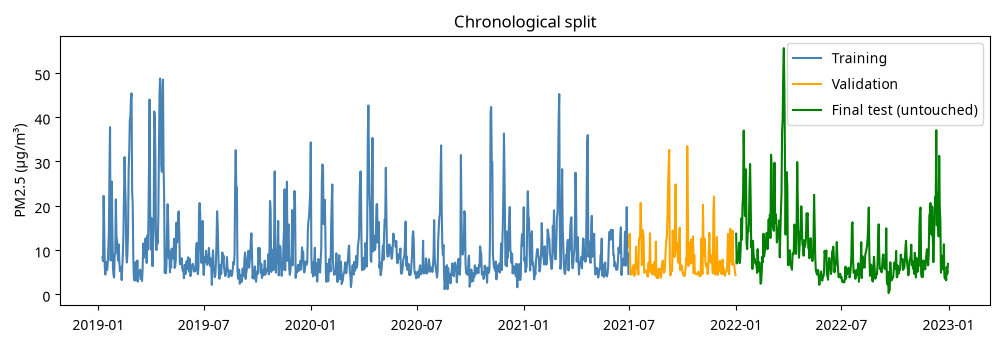

In [36]:
plt.figure(figsize=(12, 3.5))
plt.plot(model_df.loc[train_mask, "date"], y_train, color="steelblue", label="Training")
plt.plot(model_df.loc[val_mask, "date"], y_val, color="orange", label="Validation")
plt.plot(model_df.loc[test_mask, "date"], y_test, color="green", label="Final test (untouched)")
plt.title("Chronological split")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.savefig("../04_Figures/08_train_validation_test_split.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** three blocks, in time order, with no overlap.
**What it means:** the model will always be tested on days *later* than anything it trained on — exactly like real forecasting. Notice that the validation period is calmer than the others (smaller standard deviation); we will remember that when we read the validation scores.

---
# Section 9 — Preprocessing

**What we learn here:** preparing the numbers for the models.  **Why:** some models are sensitive to how numbers are scaled, and models cannot read text such as `"Winter"`.

We do two things:

1. **Categorical → numbers (one-hot encoding).** `season` becomes four 0/1 columns: `Winter`, `Spring`, `Summer`, `Autumn`. The list of four seasons is a fixed rule, so nothing is learned from the data and this is safe to do for all rows.
2. **Scale numeric features (standardisation).** Each feature is changed to *(value − mean) / standard deviation*, so all features are on a similar scale (mean 0, spread 1). This helps Linear Regression. Tree models (Random Forest, Gradient Boosting) do not need it.

⚠️ **Leakage rule:** the mean and standard deviation are calculated from the **training data only**, then applied to the other sets.

In [37]:
season_columns = pd.get_dummies(model_df["season"], dtype=int)   # 4 columns: Autumn, Spring, Summer, Winter

X_train = X_train.drop(columns="season").join(season_columns)
X_val = X_val.drop(columns="season").join(season_columns)
X_test = X_test.drop(columns="season").join(season_columns)

X_train.iloc[:, -6:].head()

,month,is_weekend,Autumn,Spring,Summer,Winter
0,1,0,0,0,0,1
1,1,0,0,0,0,1
2,1,0,0,0,0,1
3,1,0,0,0,0,1
4,1,1,0,0,0,1


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[numeric_features])        # learn mean and std from TRAINING data only

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_train_scaled[numeric_features] = scaler.transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])   # same numbers applied to validation

X_train_scaled[numeric_features].describe().loc[["mean", "std"]].round(2).iloc[:, :6]

,pm25_lag1,pm25_lag2,pm25_lag3,pm25_roll3,pm25_roll7,city_pm25_lag1
mean,-0.0,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


**What we see:** in the training data, every scaled feature now has mean ≈ 0 and standard deviation ≈ 1 (first six features shown). Validation data was transformed with the *training* numbers, so its mean is not exactly 0 — and that is correct.
**What it means:** Linear Regression will use `X_train_scaled`; the tree models will use the original `X_train`. We have created `X_test` (the season columns only) but have **not** scaled or looked at it.

---
# Section 10 — Baseline Model

**What we learn here:** how good is a *very simple* prediction?  **Why:** a machine-learning model is only impressive if it beats something simple.

**Before building ML models, what happens if we make a simple prediction?** We use two baselines:

1. **Mean baseline** — always predict the average training PM2.5. (*Is the model better than just guessing the average?*)
2. **Persistence baseline** — predict that tomorrow equals today. (*Is the model better than the obvious forecast "no change"?*)

We judge them with **MAE** (average error in µg/m³; lower is better) and **R²** (1 = perfect, 0 = no better than the average). Section 12 explains all the metrics in detail.

In [39]:
from sklearn.metrics import mean_absolute_error, r2_score

# Baseline 1: always predict the training average
mean_value = y_train.mean()
pred_mean = np.full(len(y_val), mean_value)

print("Mean baseline  -> MAE:", round(mean_absolute_error(y_val, pred_mean), 3),
      "| R²:", round(r2_score(y_val, pred_mean), 3))

Mean baseline  -> MAE: 4.456 | R²: -0.114


In [40]:
# Baseline 2: persistence = "tomorrow will be the same as today"
pred_persistence = X_val["pm25_lag1"]

print("Persistence    -> MAE:", round(mean_absolute_error(y_val, pred_persistence), 3),
      "| R²:", round(r2_score(y_val, pred_persistence), 3))

Persistence    -> MAE: 3.219 | R²: -0.022


**What we see:** the persistence baseline has a much lower MAE than the mean baseline (about 3.2 vs 4.5 µg/m³), but both have an R² close to zero on the validation period.
**What it means:** "tomorrow = today" is a strong, hard-to-beat forecast, so an ML model has to be **better than this**, not just better than the average. (R² is low here partly because the validation months are calm, so there is little variation to explain; persistence is also hurt when pollution jumps suddenly.)

---
# Section 11 — Machine Learning Models

We train three sensible models. For each one: **Explain → Train → Predict → Evaluate** (using the validation set).

We use MAE and R² here; Section 12 adds MSE and RMSE for the full comparison.

### 11.1 Linear Regression
**Explain:** draws the best straight-line relationship: *prediction = intercept + weight₁ × feature₁ + weight₂ × feature₂ + …*. Simple, fast, easy to understand. It cannot capture curved or "if-then" relationships.

In [41]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)                 # Train
pred_linear = linear_model.predict(X_val_scaled)          # Predict

print("Linear Regression -> MAE:", round(mean_absolute_error(y_val, pred_linear), 3),   # Evaluate
      "| R²:", round(r2_score(y_val, pred_linear), 3))

Linear Regression -> MAE: 3.016 | R²: 0.273


### 11.2 Random Forest
**Explain:** builds many decision trees (each asks a series of yes/no questions such as *"was yesterday's PM2.5 above 12?"*) on random parts of the data, then **averages** their answers. It can capture non-linear patterns and is hard to over-fit. It uses the unscaled data.

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)                            # Train
pred_rf = rf_model.predict(X_val)                         # Predict

print("Random Forest -> MAE:", round(mean_absolute_error(y_val, pred_rf), 3),                 # Evaluate
      "| R²:", round(r2_score(y_val, pred_rf), 3))

Random Forest -> MAE: 3.08 | R²: 0.217


### 11.3 HistGradientBoosting
**Explain:** also uses decision trees, but builds them **one after another**, and each new tree tries to fix the mistakes of the previous ones. Often very strong on tabular data, and fast.

In [43]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(X_train, y_train)                           # Train
pred_hgb = hgb_model.predict(X_val)                       # Predict

print("HistGradientBoosting -> MAE:", round(mean_absolute_error(y_val, pred_hgb), 3),           # Evaluate
      "| R²:", round(r2_score(y_val, pred_hgb), 3))

HistGradientBoosting -> MAE: 3.14 | R²: 0.146


**What we see:** all three models are in the same range, only slightly better than — or similar to — persistence on MAE. The simple Linear Regression is competitive.
**What it means:** with only ~180 validation days, small differences between models are mostly **noise**. We should not choose a model from one validation period alone — that is why we use cross-validation in Section 13.

---
# Section 12 — Regression Metrics

**What we learn here:** how to measure a regression model.

The **error** (also called residual) for one day is *actual − predicted*. Metrics summarise all the errors into one number.

| Metric | In simple words | Units | Better is |
|---|---|---|---|
| **MAE** — Mean Absolute Error | "On average, how far off are we?" | µg/m³ | lower |
| **MSE** — Mean Squared Error | Average of the *squared* errors. Big mistakes count extra. | (µg/m³)² | lower |
| **RMSE** — Root Mean Squared Error | Square root of MSE. Back in µg/m³, but still punishes big mistakes more. | µg/m³ | lower |
| **R²** | "What share of the ups and downs did we explain?" 1 = perfect, 0 = no better than guessing the average, negative = worse than that. | none | higher |

### A tiny example
Three days. Actual PM2.5 = 10, 20, 30. Predictions = 12, 18, 36.

In [44]:
from sklearn.metrics import mean_squared_error

actual = np.array([10, 20, 30])
predicted = np.array([12, 18, 36])

errors = actual - predicted
print("Errors (actual - predicted):", errors)
print("MAE  = average of |errors|     =", np.mean(np.abs(errors)).round(2))
print("MSE  = average of errors²      =", np.mean(errors ** 2).round(2))
print("RMSE = square root of MSE      =", np.sqrt(np.mean(errors ** 2)).round(2))
print("R²   (from scikit-learn)       =", round(r2_score(actual, predicted), 2))

Errors (actual - predicted): [-2  2 -6]
MAE  = average of |errors|     = 3.33
MSE  = average of errors²      = 14.67
RMSE = square root of MSE      = 3.83
R²   (from scikit-learn)       = 0.78


Notice that the one big miss (30 vs 36) pushes RMSE above MAE. **RMSE ≥ MAE always**; the bigger the gap, the more large errors there are.

### Now all baselines and models on the validation set

In [45]:
all_val_predictions = {
    "Mean baseline": pred_mean,
    "Persistence baseline": pred_persistence,
    "Linear Regression": pred_linear,
    "Random Forest": pred_rf,
    "HistGradientBoosting": pred_hgb,
}

val_results = pd.DataFrame(columns=["MAE", "MSE", "RMSE", "R²"])

for name, pred in all_val_predictions.items():
    mae = mean_absolute_error(y_val, pred)
    mse = mean_squared_error(y_val, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, pred)
    val_results.loc[name] = [mae, mse, rmse, r2]

val_results.round(3)

,MAE,MSE,RMSE,R²
Mean baseline,4.456,29.398,5.422,-0.114
Persistence baseline,3.219,26.986,5.195,-0.022
Linear Regression,3.016,19.182,4.380,0.273
Random Forest,3.080,20.662,4.546,0.217
HistGradientBoosting,3.140,22.533,4.747,0.146


**What we see:** every model beats the mean baseline. Models are close to each other and close to persistence on MAE; R² values are low because the validation period is calm and hard to explain.
**What it means:** this is **one** validation window. Before declaring a winner we need a more reliable comparison — cross-validation.

---
# Section 13 — Time-Series Cross-Validation

**What we learn here:** a more reliable way to compare models.  **Why:** one validation period can be lucky or unlucky.

### Why not ordinary cross-validation?
Ordinary (shuffled) K-fold cross-validation randomly mixes days. Some folds would **train on the future and test on the past** — leakage again. Neighbouring days are also almost identical, which would make scores look unrealistically good.

### `TimeSeriesSplit`
It creates several splits where the training part always comes **before** the validation part, and the training part grows each time:

We use only the **development period** (training + validation, i.e. up to end of 2021). The 2022 test set is not involved.

In [46]:
from sklearn.model_selection import TimeSeriesSplit

dev_mask = train_mask | val_mask
X_dev = pd.concat([X_train, X_val])
y_dev = pd.concat([y_train, y_val])
dev_dates = model_df.loc[dev_mask, "date"]

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
    print("Fold", fold,
          "| train:", dev_dates.iloc[train_idx[0]].date(), "to", dev_dates.iloc[train_idx[-1]].date(),
          "| validate:", dev_dates.iloc[val_idx[0]].date(), "to", dev_dates.iloc[val_idx[-1]].date())

Fold 1 | train: 2019-01-08 to 2019-07-10 | validate: 2019-07-11 to 2020-01-07
Fold 2 | train: 2019-01-08 to 2020-01-07 | validate: 2020-01-08 to 2020-07-06
Fold 3 | train: 2019-01-08 to 2020-07-06 | validate: 2020-07-07 to 2021-01-03
Fold 4 | train: 2019-01-08 to 2021-01-03 | validate: 2021-01-04 to 2021-07-03
Fold 5 | train: 2019-01-08 to 2021-07-03 | validate: 2021-07-04 to 2021-12-31


**What we see:** in every fold the validation dates are **after** the training dates, and each fold has more training data than the one before.
**What it means:** each fold mimics real life: *"learn from the past, forecast what comes next."*

Now we cross-validate our models. Linear Regression needs scaling, and the scaler must be re-fitted on the training part of **each fold**. `make_pipeline` does exactly that automatically (scale → then fit) — it is the only pipeline in this notebook.

In [47]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyRegressor

linear_pipe = make_pipeline(StandardScaler(), LinearRegression())

cv_mean = -cross_val_score(DummyRegressor(), X_dev, y_dev, cv=tscv, scoring="neg_mean_absolute_error")
cv_linear = -cross_val_score(linear_pipe, X_dev, y_dev, cv=tscv, scoring="neg_mean_absolute_error")
cv_rf = -cross_val_score(RandomForestRegressor(n_estimators=200, random_state=42), X_dev, y_dev, cv=tscv, scoring="neg_mean_absolute_error")
cv_hgb = -cross_val_score(HistGradientBoostingRegressor(random_state=42), X_dev, y_dev, cv=tscv, scoring="neg_mean_absolute_error")

In [48]:
# Persistence has nothing to train, so we simply measure its error on each fold's validation days
cv_persistence = []
for train_idx, val_idx in tscv.split(X_dev):
    fold_mae = mean_absolute_error(y_dev.iloc[val_idx], X_dev["pm25_lag1"].iloc[val_idx])
    cv_persistence.append(fold_mae)
cv_persistence = np.array(cv_persistence)

In [49]:
cv_results = pd.DataFrame({
    "Mean CV MAE": [cv_mean.mean(), cv_persistence.mean(), cv_linear.mean(), cv_rf.mean(), cv_hgb.mean()],
    "Std across folds": [cv_mean.std(), cv_persistence.std(), cv_linear.std(), cv_rf.std(), cv_hgb.std()],
}, index=["Mean baseline", "Persistence baseline", "Linear Regression", "Random Forest", "HistGradientBoosting"]).round(3)
cv_results.sort_values("Mean CV MAE")

,Mean CV MAE,Std across folds
Random Forest,3.299,0.243
Persistence baseline,3.359,0.178
HistGradientBoosting,3.507,0.392
Linear Regression,3.838,1.093
Mean baseline,5.231,0.844


**What we see:** averaged over five time-ordered folds, **Random Forest has the lowest error (about 3.30)** — but only slightly better than persistence (3.36). HistGradientBoosting and especially Linear Regression are *worse than persistence*. Linear Regression, which looked best on the single validation window, is also very unstable (a large standard deviation: it did badly in at least one fold).
**What it means:** the single validation period was misleading. Cross-validation gives a steadier answer, so we use it to choose the model family to tune: **Random Forest**. It also shows how hard persistence is to beat.

---
# Section 14 — Hyperparameters and GridSearchCV

### What is a hyperparameter?
- A **parameter** is something the model **learns** from the data (for example, the weights of Linear Regression).
- A **hyperparameter** is a **setting we choose before training** (for example, how deep a tree may grow).

Different settings give different results. **Hyperparameter tuning** = trying a few settings and keeping the best.

### GridSearchCV
`GridSearchCV` tries **every combination** from a small grid of settings, scores each one with cross-validation, and reports the best. We use `TimeSeriesSplit` so the search respects time order, and only the **development period** (not the test year).

For Random Forest, two important hyperparameters are:
- `max_depth` — how many questions a tree may ask in a row. Deeper = more detailed = may *over-fit* (memorise noise).
- `min_samples_leaf` — the minimum number of days in a final leaf. Larger = smoother, simpler trees.

We keep the grid small: 3 × 3 = **9 combinations**.

In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [5, 10, None],          # None = no limit
    "min_samples_leaf": [1, 5, 10],
}

grid = GridSearchCV(
    RandomForestRegressor(n_estimators=200, random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
)
grid.fit(X_dev, y_dev)

print("Best settings:", grid.best_params_)
print("Best CV MAE:  ", round(-grid.best_score_, 3))

Best settings: {'max_depth': 10, 'min_samples_leaf': 5}
Best CV MAE:   3.191


In [51]:
grid_table = pd.DataFrame(grid.cv_results_)[["param_max_depth", "param_min_samples_leaf", "mean_test_score"]]
grid_table["CV MAE"] = -grid_table["mean_test_score"]
grid_table = grid_table.drop(columns="mean_test_score").sort_values("CV MAE").round(3)
grid_table.rename(columns={"param_max_depth": "max_depth", "param_min_samples_leaf": "min_samples_leaf"})

,max_depth,min_samples_leaf,CV MAE
4,10,5,3.191
1,5,5,3.192
7,None,5,3.194
5,10,10,3.205
8,None,10,3.206
2,5,10,3.207
0,5,1,3.265
6,None,1,3.299
3,10,1,3.300


**What we see:** the setting that matters is `min_samples_leaf`: leaves of 5 or 10 days give a CV MAE of about 3.19–3.21, while leaves of 1 day (fully detailed trees that memorise noise) give about 3.26–3.30. `max_depth` makes almost no difference. The best CV MAE (3.19) is about 3% better than the untuned forest (3.30).
**What it means:** tuning gave a *modest* improvement, which is typical. The big wins in this project come from good features and honest evaluation, not from endless tuning. Also note that the best CV score is slightly optimistic, because we picked it as the best of nine tries.

---
# Section 15 — Model Comparison and Final Model

**What we learn here:** choosing the final model, and evaluating it honestly.

### Step 1 — Compare everything using validation / CV results only
We train the tuned Random Forest on the training period (so we can score it on the validation period like the others).

In [52]:
rf_tuned_train = RandomForestRegressor(n_estimators=200, random_state=42, **grid.best_params_)
rf_tuned_train.fit(X_train, y_train)
pred_rf_tuned = rf_tuned_train.predict(X_val)

In [53]:
comparison = pd.DataFrame({
    "Validation MAE": [
        mean_absolute_error(y_val, pred_mean),
        mean_absolute_error(y_val, pred_persistence),
        mean_absolute_error(y_val, pred_linear),
        mean_absolute_error(y_val, pred_rf),
        mean_absolute_error(y_val, pred_hgb),
        mean_absolute_error(y_val, pred_rf_tuned),
    ],
    "CV MAE": [cv_mean.mean(), cv_persistence.mean(), cv_linear.mean(), cv_rf.mean(), cv_hgb.mean(), -grid.best_score_],
}, index=["Mean baseline", "Persistence baseline", "Linear Regression", "Random Forest",
          "HistGradientBoosting", "Tuned Random Forest"]).round(3)
comparison.sort_values("CV MAE")

,Validation MAE,CV MAE
Tuned Random Forest,2.985,3.191
Random Forest,3.080,3.299
Persistence baseline,3.219,3.359
HistGradientBoosting,3.140,3.507
Linear Regression,3.016,3.838
Mean baseline,4.456,5.231


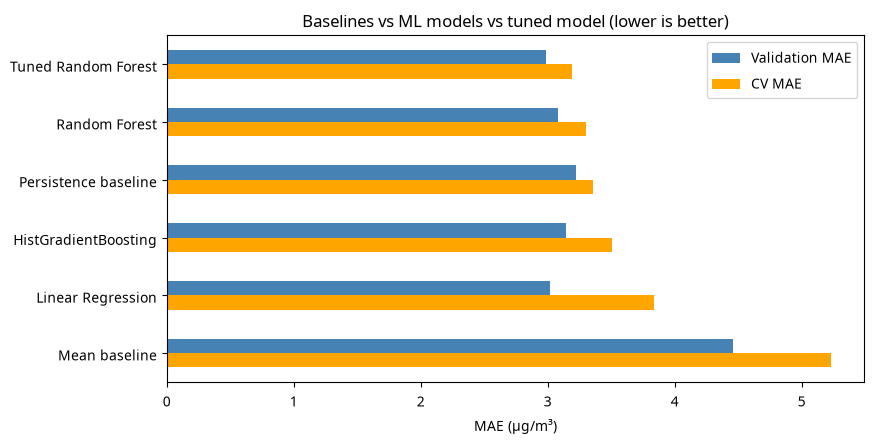

In [54]:
comparison.sort_values("CV MAE").plot(kind="barh", figsize=(9, 4.5), color=["steelblue", "orange"])
plt.title("Baselines vs ML models vs tuned model (lower is better)")
plt.xlabel("MAE (µg/m³)")
plt.gca().invert_yaxis()
plt.savefig("../04_Figures/09_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** the tuned Random Forest has the lowest CV MAE (3.19) and also the lowest validation MAE (2.99). The gap to persistence is small (CV 3.36).
**What it means:** we select the **tuned Random Forest** as the final model, because it is best on the *time-aware cross-validation* (the most reliable evidence we have, built from five validation windows rather than one) and also best on the validation period. We did not use the test set to choose it.

### Step 2 — Evaluate the final model once on the untouched 2022 test period
`GridSearchCV` has already re-trained the best model on the whole development period (2019 → 2021). Now — **for the first and only time** — we predict 2022.

**Why only once?** The test set is our simulation of "the future". If we kept testing and changing the model until the test score looked good, we would be fooling ourselves, exactly like leakage.

In [55]:
final_model = grid.best_estimator_          # tuned Random Forest, trained on 2019-2021
pred_test = final_model.predict(X_test)     # first and only look at 2022

# Baselines on the test year, for fair comparison
pred_test_mean = np.full(len(y_test), y_dev.mean())
pred_test_persistence = X_test["pm25_lag1"]

In [56]:
all_test_predictions = {
    "Mean baseline": pred_test_mean,
    "Persistence baseline": pred_test_persistence,
    "Tuned Random Forest (final)": pred_test,
}

test_results = pd.DataFrame(columns=["MAE", "MSE", "RMSE", "R²"])

for name, pred in all_test_predictions.items():
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    test_results.loc[name] = [mae, mse, np.sqrt(mse), r2_score(y_test, pred)]

test_results.round(3)

,MAE,MSE,RMSE,R²
Mean baseline,5.200,57.509,7.583,-0.004
Persistence baseline,3.256,24.544,4.954,0.572
Tuned Random Forest (final),3.227,23.534,4.851,0.589


**What we see:** on the unseen 2022 data, the final model has MAE 3.23, RMSE 4.85 and R² 0.59 (it explains about 59% of the variation). The mean baseline has R² ≈ 0, and persistence gets MAE 3.26 and R² 0.57.
**What it means:** the model genuinely works on new data, and its test MAE (3.23) is close to the CV MAE (3.19) — a good sign that we did not over-fit. But the improvement over "tomorrow = today" is **very small** (about 1% in MAE), and we should say so honestly.

---
# Section 16 — Actual vs Predicted

**What we learn here:** how the predictions look in practice.  **Why:** one number (MAE) hides *when* the model succeeds and fails.

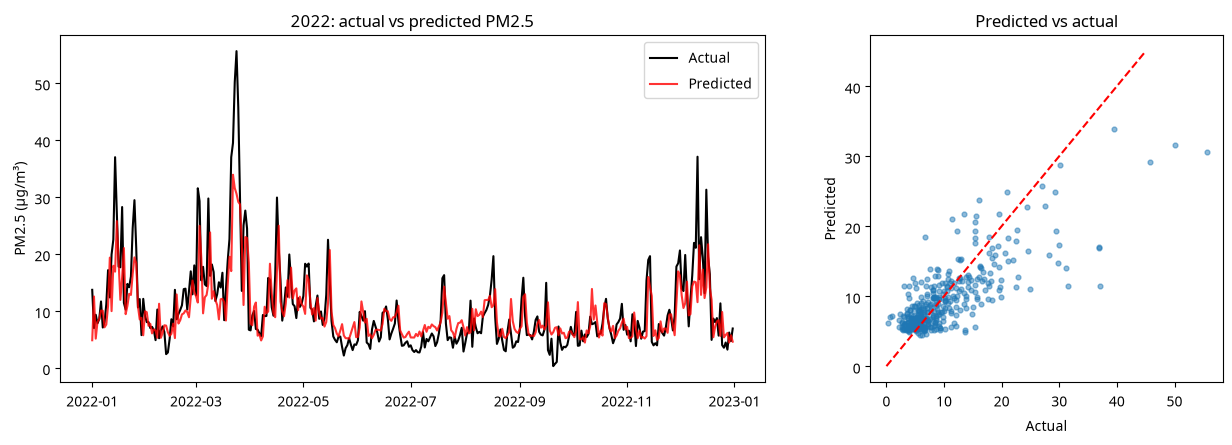

In [57]:
test_dates = model_df.loc[test_mask, "date"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})

axes[0].plot(test_dates, y_test.values, color="black", label="Actual")
axes[0].plot(test_dates, pred_test, color="red", alpha=0.8, label="Predicted")
axes[0].set_title("2022: actual vs predicted PM2.5")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].legend()

axes[1].scatter(y_test, pred_test, s=12, alpha=0.5)
axes[1].plot([0, 45], [0, 45], color="red", linestyle="--")      # perfect prediction line
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].set_title("Predicted vs actual")

plt.savefig("../04_Figures/10_actual_vs_predicted.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:**
- *Left:* the red line follows the black line's general ups and downs, but the red line is **smoother** and its peaks are **lower**.
- *Right:* points close to the dashed line are good predictions. At low values the points are near the line; at high values they fall **below** it.

**What it means:**
- **Good:** ordinary days and gradual changes.
- **Struggles:** sudden spikes and the highest-pollution days — the model **under-predicts** them, because it only knows about yesterday and cannot see a pollution event coming.
- **A one-day delay:** look closely at the peaks — the red line often rises *a day after* the black line. This is the signature of a model that leans heavily on yesterday's value (which is also why it only slightly beats persistence).

---
# Section 17 — Error Analysis

**What we learn here:** where and why the model is wrong.  **Why:** the average error hides the days that matter most.

The **error (residual)** = actual − predicted. *Positive* = we predicted too low; *negative* = we predicted too high.

In [58]:
errors = pd.DataFrame({
    "date": test_dates.values,
    "actual": y_test.values,
    "predicted": pred_test,
})
errors["error"] = errors["actual"] - errors["predicted"]
errors["abs_error"] = errors["error"].abs()

errors.nlargest(5, "abs_error").round({"actual": 2, "predicted": 2, "error": 2, "abs_error": 2})

,date,actual,predicted,error,abs_error
344,2022-12-11,37.04,11.50,25.54,25.54
82,2022-03-24,55.58,30.54,25.05,25.05
13,2022-01-14,36.96,16.86,20.10,20.10
60,2022-03-02,31.50,11.44,20.06,20.06
79,2022-03-21,36.96,16.96,20.00,20.00


**Large errors.** These are the five days with the biggest mistakes.

In [59]:
print("Share of days with an error below 3 µg/m³:", round((errors["abs_error"] < 3).mean() * 100), "%")
print("Share of days with an error above 8 µg/m³:", round((errors["abs_error"] > 8).mean() * 100), "%")

Share of days with an error below 3 µg/m³: 65 %
Share of days with an error above 8 µg/m³: 8 %


**Small vs large errors:** about two-thirds of days have an error below 3 µg/m³, but about 8% of days are off by more than 8 µg/m³. The five worst days were all real pollution episodes (actual 31–56 µg/m³) that the model predicted much too low. These few days are what push RMSE (4.85) well above MAE (3.23).

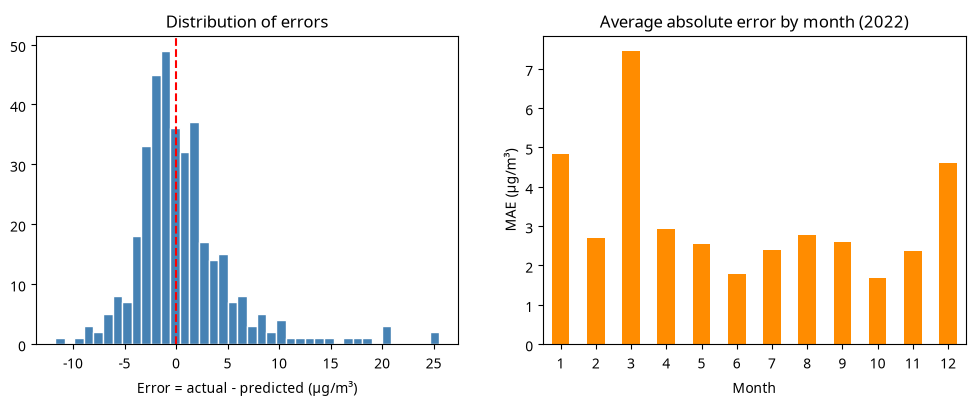

Average error (bias): 0.6 µg/m³ (positive = predicted too low on average)


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(errors["error"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Distribution of errors")
axes[0].set_xlabel("Error = actual - predicted (µg/m³)")

errors["month"] = errors["date"].dt.month
errors.groupby("month")["abs_error"].mean().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Average absolute error by month (2022)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("MAE (µg/m³)")
axes[1].tick_params(axis="x", rotation=0)

plt.savefig("../04_Figures/11_error_distribution_and_time.png", dpi=120, bbox_inches="tight")
plt.show()

print("Average error (bias):", round(errors["error"].mean(), 2), "µg/m³ (positive = predicted too low on average)")

**What we see:** *Left:* most errors are close to zero, but the right tail is much longer — large *positive* errors, meaning we predicted too low. On average the model is slightly too low (about +0.6 µg/m³). *Right:* the error changes through the year: **March is by far the hardest month** (about 7.5), followed by January and December (about 4.6–4.8), while June and October are easiest (under 2).
**What it means:** errors are **not constant over time** — they are largest in the months with pollution episodes (winter and early spring) and small in calm, clean months. The model is fairly accurate on ordinary days but misses spikes (too low).

### Are high-pollution days harder to predict?

In [61]:
levels = pd.cut(errors["actual"], bins=[0, 5, 10, 15, 25, 100],
                labels=["0-5", "5-10", "10-15", "15-25", "25+"])

error_by_level = errors.groupby(levels, observed=True).agg(
    days=("actual", "size"),
    average_abs_error=("abs_error", "mean"),
    average_error=("error", "mean"),
).round(2)
error_by_level

,days,average_abs_error,average_error
actual,,,
0-5,77,2.92,-2.92
5-10,157,1.72,-0.51
10-15,62,2.93,1.46
15-25,52,5.23,3.89
25+,17,13.55,13.55


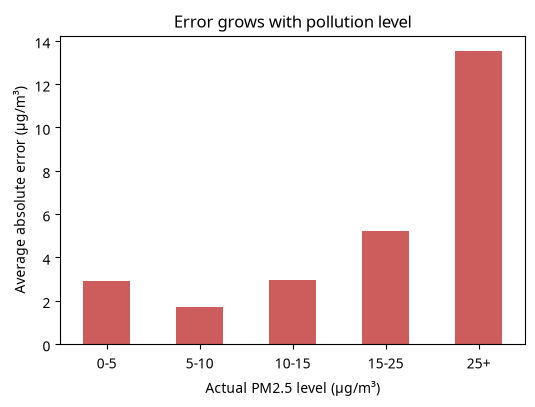

In [62]:
error_by_level["average_abs_error"].plot(kind="bar", figsize=(6, 4), color="indianred")
plt.title("Error grows with pollution level")
plt.xlabel("Actual PM2.5 level (µg/m³)")
plt.ylabel("Average absolute error (µg/m³)")
plt.xticks(rotation=0)
plt.savefig("../04_Figures/12_error_by_pollution_level.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** the error is smallest for ordinary days (5–10 µg/m³: about 1.7) and grows steeply for polluted days: about 5 for 15–25 µg/m³, and about **13.6** for days above 25 µg/m³. For the highest group the average error is strongly **positive** (the model predicts about 13.6 too low). For the cleanest group it is negative — the model predicts slightly too high.
**What it means:** **yes, high-pollution days are much harder to predict.** The model is pulled toward the average ("regression to the mean"). This matters, because high-pollution days are exactly the days people care about.

---
# Section 18 — Feature Importance / Interpretation

**What we learn here:** which features the model relies on.  **Why:** to check that the model makes sense and to learn something about air pollution.

We use **permutation importance**, a simple idea: *shuffle one feature's values and see how much the model gets worse.* If the error jumps up, the feature was important.

To avoid peeking at the test year, we use the tuned Random Forest trained on the **training period** and measure importance on the **validation period**.

In [63]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf_tuned_train, X_val, y_val, n_repeats=10,
                              random_state=42, scoring="neg_mean_absolute_error")

importance = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance (increase in MAE)": perm.importances_mean,
}).sort_values("Importance (increase in MAE)", ascending=False)

importance.head(10).round(3)

,Feature,Importance (increase in MAE)
0,pm25_lag1,0.484
9,ws_lag1,0.131
11,wd_sin_lag1,0.120
5,city_pm25_lag1,0.070
6,pm10_lag1,0.056
13,ws_roll3,0.037
7,no2_lag1,0.036
1,pm25_lag2,0.029
10,rh_lag1,0.020
8,temp_lag1,0.014


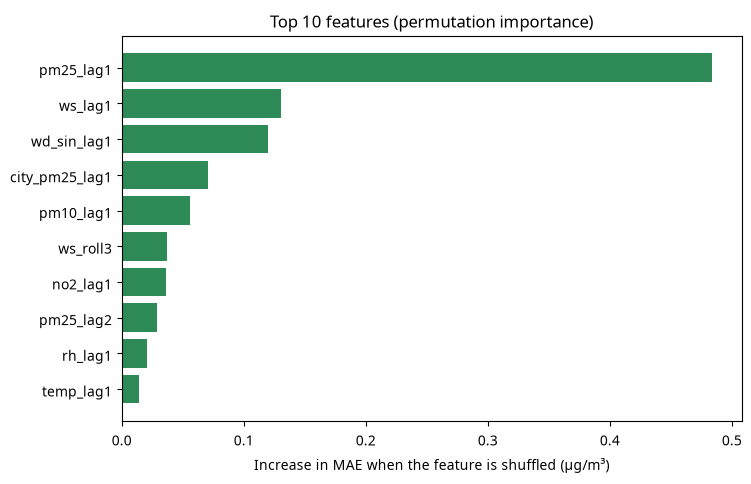

In [64]:
top10 = importance.head(10).sort_values("Importance (increase in MAE)")

plt.figure(figsize=(8, 5))
plt.barh(top10["Feature"], top10["Importance (increase in MAE)"], color="seagreen")
plt.title("Top 10 features (permutation importance)")
plt.xlabel("Increase in MAE when the feature is shuffled (µg/m³)")
plt.savefig("../04_Figures/13_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** **yesterday's PM2.5 (`pm25_lag1`) is by far the most important feature** (shuffling it raises the error by about 0.48 µg/m³). Next come yesterday's wind speed (`ws_lag1`, 0.13) and wind direction (`wd_sin_lag1`, 0.12), then city-wide PM2.5 and PM10 from yesterday. The rolling means, satellite features, `month`, `season` and `is_weekend` contribute almost nothing (about 0 or less than 0.01).

**What it means in air-pollution terms:**
- **Yesterday's PM2.5 matters most:** particles hang around for days, so yesterday's level is the best clue for tomorrow's.
- **Wind speed and direction matter:** wind sweeps pollution away or brings it in from the east (as the EDA showed).
- **Rolling means add little** because they mostly repeat information already in the lag features.
- **Calendar and satellite features barely matter:** season changes slowly and yesterday's pollution already captures most of it; vegetation/building indices hardly change from day to day.

⚠️ Importance means *"useful for prediction"*, **not** *"causes pollution"*. Also, features that are related to each other (e.g. lag 1 and the 3-day average) share the credit, so single values should not be over-interpreted.

---
# Section 19 — Risk Analysis

Practical things that could make this project's results misleading:

| Risk | Why it matters | What we did about it |
|---|---|---|
| **Data leakage** | Using today's or future data would make results look fake-good | Lagged features with `shift(1)` first; chronological split; scaler fitted on training only; test used once |
| **Temporal dependence** | Neighbouring days are very similar, so ordinary cross-validation is too optimistic | `TimeSeriesSplit` instead of random folds |
| **Unusual pollution events** | Rare spikes (e.g. episodes, fireworks, weather events) are hard to predict and are under-predicted | Kept these days in the data (they are real); analysed errors by pollution level |
| **Limited dataset period** | Only four years (2019–2022), including the unusual COVID-19 period | Honest reporting; no claim that this holds for other years |
| **Model generalisation** | A model may work in 2022 but fail in another city or year | Used an untouched test year; compared CV and test scores (they agree) |
| **Small gain over persistence** | A complicated model that barely beats "tomorrow = today" may not be worth it | Included persistence as a baseline and reported the small gain |

---
# Section 20 — Limitations

What this project **cannot** prove:

- **It is a prediction project, not a causal one.** It shows what is *useful for forecasting*, not what *causes* pollution.
- **One city and one station.** The result may not carry over to other places.
- **One short period (2019–2022),** including pandemic-era behaviour, so patterns may differ in other years.
- **Weather is yesterday's observed weather,** not a real next-day weather forecast. A real system could do better with weather forecasts.
- **Daily averages** hide what happens within the day (e.g. rush hours).
- **Missing values had already been filled in** by the dataset authors before publication.
- **High-pollution days are under-predicted,** which is a real weakness.
- **The improvement over persistence is small.**
- **Real-world use would need more work:** testing on more years and places, monitoring, retraining, and reliable incoming measurements. This notebook is a learning project, not a forecasting service.

---
# Section 21 — Final Conclusion

### What we learned about the data
PM2.5 at Camden–Bloomsbury is right-skewed, follows a yearly pattern (higher in late winter/spring, lowest in summer), is lower on windy days, and — most importantly — has **memory**: yesterday's PM2.5 is the best clue for tomorrow's.

### Which features were useful
**Yesterday's PM2.5** was by far the most useful feature, followed by **wind speed and wind direction** and yesterday's city-wide PM2.5 and PM10. Rolling means, calendar features and satellite vegetation/building indices added almost nothing.

### Which model performed best
After time-aware cross-validation and a small `GridSearchCV`, the **tuned Random Forest** was selected. It was chosen using only the 2019–2021 development period.

### How well it performed (untouched 2022 test)
| Model | MAE (µg/m³) | RMSE (µg/m³) | R² |
|---|---|---|---|
| Mean baseline | 5.20 | 7.58 | −0.00 |
| Persistence baseline ("tomorrow = today") | 3.26 | 4.95 | 0.57 |
| **Tuned Random Forest (final)** | **3.23** | **4.85** | **0.59** |

The model clearly beats the mean baseline, but beats persistence by only about 1% in MAE. Development CV MAE was 3.19, close to the 3.23 test MAE.

### Important limitations
One station, four years, observed (not forecast) weather, strong under-prediction of high-pollution days (days above 25 µg/m³ are predicted about 13.6 µg/m³ too low on average), and a very small gain over "tomorrow = today". It is a predictive tool, not proof of cause and effect.

### The overall workflow
**Understand → Explore → Prepare → Create Features → Prevent Leakage → Split → Train → Evaluate → Tune → Interpret → Conclude.**

The biggest lessons are not about the algorithm: **(1)** build features only from the past, **(2)** split by time, **(3)** always compare against a simple baseline, and **(4)** touch the test set once.